### Step 0 :- Import Libraries

In [1]:
# Import Path for file handling
from pathlib import Path

# Import KaggleHub
import kagglehub

# Import Pandas
import pandas as pd

# Import NumPy
import numpy as np

# Import Matplotlib
import matplotlib.pyplot as plt

# Import train-test split
from sklearn.model_selection import train_test_split

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Import model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report)

### Step 1 :- Authenticate with Kaggle

> Before downloading any Kaggle dataset or competition files, authentication is required.

> In this notebook, we will use the **getpass()** method.

#### Why use getpass()?

> - Hides the API Token while typing.
> - Prevents accidental exposure of sensitive credentials.
> - Safer than hardcoding the API Token.
> - Recommended for learning and demonstration notebooks.

> **Note**

> - Enter your Kaggle API Token when prompted.

> - Your input will remain hidden while typing.

In [2]:
# Import required modules
import os
from getpass import getpass

# Prompt the user to securely enter the Kaggle API Token
api_token = getpass('Enter your Kaggle API Token: ')

# Store the API Token as an environment variable
os.environ['KAGGLE_API_TOKEN'] = api_token

# Display a confirmation message
print('Authentication completed successfully.')

Enter your Kaggle API Token:  ········


Authentication completed successfully.


### Step 2 :- Download the Dataset

> Download the latest dataset files using KaggleHub.

> Dataset Name

> - Credit Card Fraud Detection

In [3]:
# Download the latest dataset files
dataset_path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')

# Display the download location
print(dataset_path)

C:\Users\neyaz\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


### Step 3 :- Create the Dataset Path

> Convert the downloaded dataset path into a `Path` object.

> Using the `Path` class makes file handling easier, cleaner, and platform-independent (Windows, Linux, and macOS).

In [4]:
# Convert the downloaded dataset path into a Path object
dataset_path = Path(dataset_path)

### Step 4 :- Display Available Files

> Display all files available in the competition folder.

In [5]:
# Display all available files
list(dataset_path.iterdir())

[WindowsPath('C:/Users/neyaz/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3/creditcard.csv')]

### Step 5 :- Load the Datasets

In [6]:
# Load the dataset
credit_card_data = pd.read_csv(dataset_path / 'creditcard.csv')

#### Display Dataset Information

In [7]:
# Display dataset shape
print(f'Dataset Shape: {credit_card_data.shape}')

# Display column names
print(f'\nColumns:\n{credit_card_data.columns}')

# Display first 5 rows
credit_card_data.head()

Dataset Shape: (284807, 31)

Columns:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#### Check Dataset Information

In [8]:
# Display dataset information
credit_card_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

### Step 6 :- Exploratory Data Analysis

#### Display First 5 Rows

In [9]:
# Display first 5 rows
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#### Display Last 5 Rows

In [10]:
# Display last 5 rows
credit_card_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


#### Check Dataset Shape

In [11]:
# Display dataset shape
print(f'Rows: {credit_card_data.shape[0]}')

print(f'Columns: {credit_card_data.shape[1]}')

Rows: 284807
Columns: 31


#### Check Data Types

In [12]:
# Display data types
credit_card_data.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

#### Check Missing Values

In [13]:
# Display missing values
credit_card_data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

#### Check Duplicate Records

In [14]:
# Display duplicate records
print(f'Duplicate Records: {credit_card_data.duplicated().sum()}')

Duplicate Records: 1081


#### Display Summary Statistics

In [15]:
# Display summary statistics
credit_card_data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


#### Display Feature Names

In [16]:
# Display column names
credit_card_data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

#### Check Target Variable Distribution

In [17]:
# Display transaction class distribution
credit_card_data['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

#### Display Target Variable Percentage

In [18]:
# Display transaction class percentage
credit_card_data['Class'].value_counts(normalize = True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

#### Fraud vs Normal Transactions

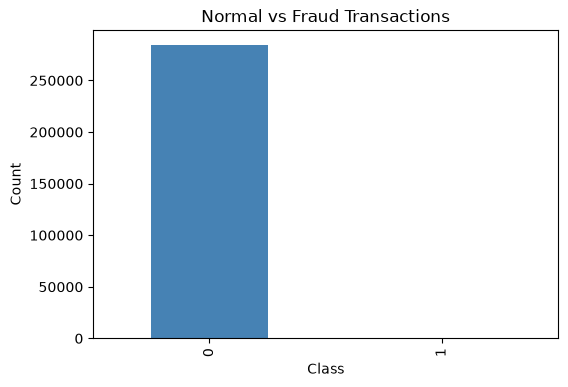

In [19]:
# Create figure
plt.figure(figsize = (6, 4))

# Plot class distribution
credit_card_data['Class'].value_counts().plot(

    kind = 'bar',

    color = ['steelblue', 'red'])

# Chart title
plt.title('Normal vs Fraud Transactions')

# X-axis label
plt.xlabel('Class')

# Y-axis label
plt.ylabel('Count')

# Display chart
plt.show()

### Step 7 :- Data Preprocessing

#### Remove Missing Values

In [20]:
# Remove missing values
credit_card_data = credit_card_data.dropna()

# Display dataset shape
print(f'Dataset Shape: {credit_card_data.shape}')

Dataset Shape: (284807, 31)


#### Remove Duplicate Records

In [21]:
# Remove duplicate records
credit_card_data = credit_card_data.drop_duplicates()

# Display duplicate records
print(f'Duplicate Records: {credit_card_data.duplicated().sum()}')

Duplicate Records: 0


#### Select Input Features

In [22]:
# Select input features
X = credit_card_data.drop('Class', axis = 1)

X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


#### Select Target Variable

In [23]:
# Select target variable
y = credit_card_data['Class']

y.head()

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64

#### Split Dataset

In [24]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size = 0.2,

    random_state = 42,

    stratify = y)

#### Display Dataset Shape

In [25]:
# Display dataset shape
print(f'Training Data: {X_train.shape}')

print(f'Testing Data: {X_test.shape}')

Training Data: (226980, 30)
Testing Data: (56746, 30)


#### Verify Training Data

In [26]:
# Display training data
X_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
226238,144549.0,2.238954,-1.724499,-2.151484,-2.577803,0.993668,3.565492,-1.785957,0.860122,-1.264003,...,-0.323810,-0.149574,-0.049333,0.278442,0.684735,-0.219028,-0.159167,0.037920,-0.049932,32.00
134253,80716.0,-1.315062,1.630783,0.597001,-0.038359,-0.404580,-0.965712,0.212249,0.735381,-1.267926,...,-0.067580,-0.238898,-0.946773,0.323904,0.515632,-0.713000,-0.266503,-0.017794,0.051058,6.99
186465,127116.0,1.908801,0.021184,-2.087997,0.129310,1.161468,0.605244,-0.022371,0.180296,0.283819,...,-0.210474,0.293609,1.095842,-0.044874,-1.689517,0.106098,0.007758,0.045164,-0.053068,14.95
149493,91342.0,1.811257,0.316556,0.316751,3.880231,0.048454,1.020163,-0.734868,0.233651,0.681423,...,-0.228032,0.138869,0.700422,0.174064,0.702997,-0.212523,-0.010018,-0.017740,-0.038006,17.30
18461,29522.0,1.358817,-1.120881,0.550266,-1.547659,-1.194950,0.275448,-1.201843,0.212889,-2.094285,...,-0.361686,-0.340972,-0.636442,0.252758,-0.344160,-0.064282,-0.439622,0.062524,0.013095,24.00


#### Verify Testing Data

In [27]:
# Display testing data
X_test.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
86568,61290.0,1.228821,-0.063408,0.274145,0.647465,-0.048135,0.372073,-0.224231,0.079939,0.640759,...,-0.096566,-0.129554,-0.083779,-0.151661,-0.700372,0.598550,0.491409,0.002989,0.001782,11.50
251557,155394.0,-0.203154,1.176678,-0.759595,-0.518472,0.629649,-0.721675,0.638893,0.243377,-0.157488,...,-0.098429,0.384629,1.206754,-0.082753,0.508386,-0.710906,-0.234510,0.379640,0.261351,1.94
20232,30881.0,-1.672836,1.401297,1.503940,2.175491,0.699791,1.062139,1.114364,-0.535822,-0.252983,...,0.828472,-0.525950,-0.408743,-0.280083,-0.846468,-0.155456,-0.062383,0.007777,0.113900,91.28
68952,53203.0,0.819379,-1.124913,0.515025,0.513945,-1.009048,0.488484,-0.580672,0.187686,-0.999142,...,-0.110144,-0.057205,-0.168061,-0.198732,-0.337408,0.238538,-0.289454,0.038214,0.058407,228.00
191852,129429.0,2.009701,0.105635,-1.752759,0.588312,0.374801,-0.637884,0.009260,-0.129487,0.492619,...,-0.135479,0.008970,0.357394,-0.013472,-0.446920,0.111522,0.642944,-0.036998,-0.043404,1.41


### Step 8 :- Model Training

#### Create Logistic Regression Model

In [28]:
# Create Logistic Regression model
logistic_regression_model = LogisticRegression(

    max_iter = 5000,

    random_state = 42)

#### Train Model

In [29]:
# Train model
logistic_regression_model.fit(

    X_train,

    y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

#### Predict Transaction Class

In [30]:
# Predict transaction class
predicted_class = logistic_regression_model.predict(

    X_test)

predicted_class[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

#### Predict Fraud Probability

In [31]:
# Predict fraud probability
predicted_probability = logistic_regression_model.predict_proba(

    X_test)

predicted_probability[:10]

array([[9.99732337e-01, 2.67663121e-04],
       [9.99717970e-01, 2.82029833e-04],
       [9.99985524e-01, 1.44759957e-05],
       [9.99908154e-01, 9.18458240e-05],
       [9.98549366e-01, 1.45063435e-03],
       [9.99690072e-01, 3.09927898e-04],
       [9.99933662e-01, 6.63384684e-05],
       [9.99805049e-01, 1.94951055e-04],
       [9.99941390e-01, 5.86100884e-05],
       [9.99822634e-01, 1.77365574e-04]])

#### Compare Actual vs Predicted Values

In [32]:
# Compare actual and predicted values
prediction_results = pd.DataFrame({

    'Actual Class': y_test.values,

    'Predicted Class': predicted_class})

prediction_results.head(10)

,Actual Class,Predicted Class
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


#### Display Number of Predictions

In [33]:
# Display prediction count
print(

    f'Total Predictions: {len(predicted_class)}')

Total Predictions: 56746


### Step 9 :- Model Evaluation

#### Calculate Accuracy Score

In [34]:
# Calculate accuracy score
accuracy = accuracy_score(

    y_test,

    predicted_class)

print(

    f'Accuracy Score: {accuracy:.4f}')

Accuracy Score: 0.9991


#### Calculate Precision Score

In [35]:
# Calculate precision score
precision = precision_score(

    y_test,

    predicted_class)

print(

    f'Precision Score: {precision:.4f}')

Precision Score: 0.8462


#### Calculate Recall Score

In [36]:
# Calculate recall score
recall = recall_score(

    y_test,

    predicted_class)

print(

    f'Recall Score: {recall:.4f}')

Recall Score: 0.5789


#### Calculate F1 Score

In [37]:
# Calculate F1 score
f1 = f1_score(

    y_test,

    predicted_class)

print(

    f'F1 Score: {f1:.4f}')

F1 Score: 0.6875


#### Display Confusion Matrix

In [38]:
# Display confusion matrix
confusion_matrix(

    y_test,

    predicted_class)

array([[56641,    10],
       [   40,    55]])

#### Display Classification Report

In [39]:
# Display classification report
print(

    classification_report(

        y_test,

        predicted_class))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746



#### Display Model Performance

In [40]:
# Display model performance
model_performance = pd.DataFrame({

    'Metric': [

        'Accuracy Score',

        'Precision Score',

        'Recall Score',

        'F1 Score'],

    'Value': [

        accuracy,

        precision,

        recall,

        f1]})

model_performance

,Metric,Value
0,Accuracy Score,0.999119
1,Precision Score,0.846154
2,Recall Score,0.578947
3,F1 Score,0.687500


#### Model Accuracy

In [41]:
# Display model accuracy
print(

    f'Model Accuracy: {accuracy * 100:.2f}%')

Model Accuracy: 99.91%


### Step 10 :- Prediction

#### Predict Transaction Class

In [42]:
# Predict transaction class
predicted_class = logistic_regression_model.predict(

    X_test)

predicted_class[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

#### Predict Fraud Probability

In [43]:
# Predict fraud probability
predicted_probability = logistic_regression_model.predict_proba(

    X_test)

prediction_probability = pd.DataFrame(

    predicted_probability,

    columns = [

        'Normal Probability',

        'Fraud Probability'])

prediction_probability.head(10)

,Normal Probability,Fraud Probability
0,0.999732,0.000268
1,0.999718,0.000282
2,0.999986,0.000014
3,0.999908,0.000092
4,0.998549,0.001451
5,0.999690,0.000310
6,0.999934,0.000066
7,0.999805,0.000195
8,0.999941,0.000059
9,0.999823,0.000177


#### Compare Actual vs Predicted Transactions

In [44]:
# Compare actual and predicted transactions
prediction_results = pd.DataFrame({

    'Actual Class': y_test.values,

    'Predicted Class': predicted_class})

prediction_results.head(10)

,Actual Class,Predicted Class
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


#### Predict a New Transaction

In [45]:
# Create a new transaction
new_transaction = pd.DataFrame(

    [X.iloc[0].values],

    columns = X.columns)

# Predict transaction class
prediction = logistic_regression_model.predict(

    new_transaction)

print(

    f'Predicted Class: {prediction[0]}')

Predicted Class: 0


#### Predict Fraud Probability for New Transaction

In [46]:
# Predict fraud probability
fraud_probability = logistic_regression_model.predict_proba(

    new_transaction)

print(

    f'Fraud Probability: {fraud_probability[0][1]:.4f}')

Fraud Probability: 0.0003


#### Prediction Summary

In [47]:
# Display total predictions
print(

    f'Total Predictions: {len(predicted_class)}')

Total Predictions: 56746


### Step 11 :- Visualization

#### Actual vs Predicted Transactions

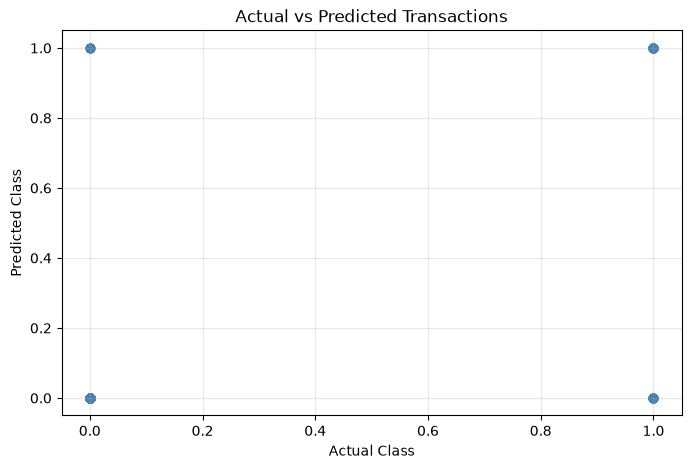

In [48]:
# Create figure
plt.figure(figsize = (8, 5))

# Plot actual vs predicted
plt.scatter(

    y_test,

    predicted_class,

    color = 'steelblue')

# Chart title
plt.title('Actual vs Predicted Transactions')

# X-axis label
plt.xlabel('Actual Class')

# Y-axis label
plt.ylabel('Predicted Class')

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Normal vs Fraud Transactions

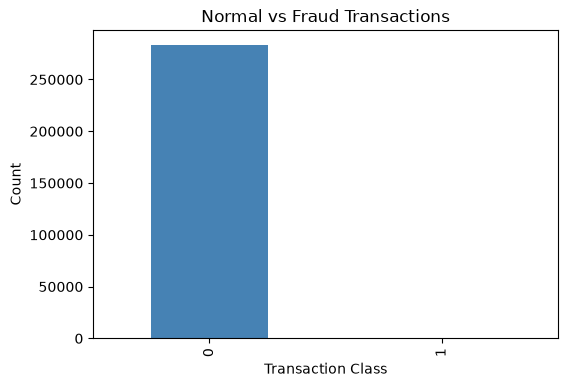

In [49]:
# Create figure
plt.figure(figsize = (6, 4))

# Plot transaction distribution
credit_card_data['Class'].value_counts().plot(

    kind = 'bar',

    color = ['steelblue', 'red'])

# Chart title
plt.title('Normal vs Fraud Transactions')

# X-axis label
plt.xlabel('Transaction Class')

# Y-axis label
plt.ylabel('Count')

# Display chart
plt.show()

#### Prediction Comparison

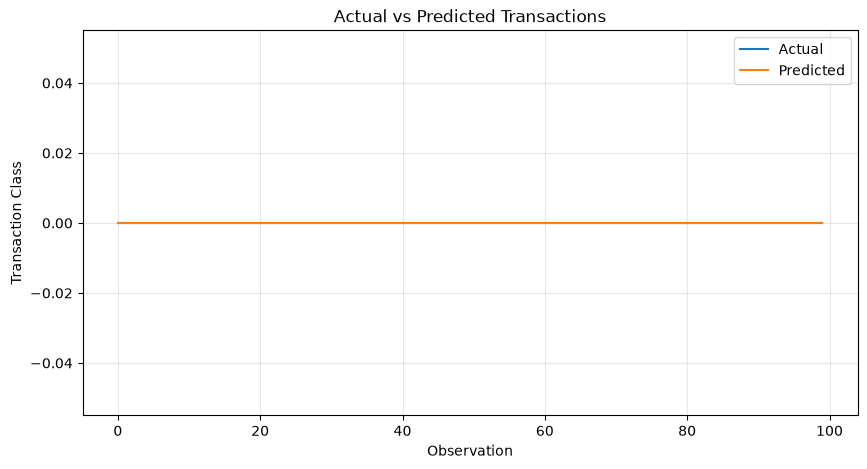

In [50]:
# Create figure
plt.figure(figsize = (10, 5))

# Plot actual values
plt.plot(

    y_test.values[:100],

    label = 'Actual')

# Plot predicted values
plt.plot(

    predicted_class[:100],

    label = 'Predicted')

# Chart title
plt.title('Actual vs Predicted Transactions')

# X-axis label
plt.xlabel('Observation')

# Y-axis label
plt.ylabel('Transaction Class')

# Show legend
plt.legend()

# Show grid
plt.grid(alpha = 0.3)

# Display chart
plt.show()

#### Confusion Matrix Visualization

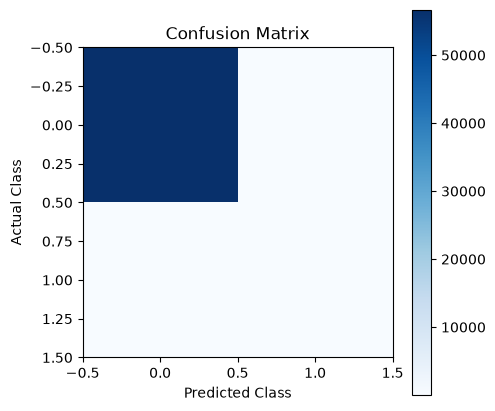

In [51]:
# Create confusion matrix
confusion = confusion_matrix(

    y_test,

    predicted_class)

# Create figure
plt.figure(figsize = (5, 5))

# Display confusion matrix
plt.imshow(

    confusion,

    cmap = 'Blues')

# Add title
plt.title('Confusion Matrix')

# Add color bar
plt.colorbar()

# Axis labels
plt.xlabel('Predicted Class')

plt.ylabel('Actual Class')

# Display chart
plt.show()

#### Model Performance Summary

In [52]:
# Display model performance
model_performance

,Metric,Value
0,Accuracy Score,0.999119
1,Precision Score,0.846154
2,Recall Score,0.578947
3,F1 Score,0.687500


### Step 12 :- Information

> Dataset: Credit Card Fraud Detection

> Source File:
> - creditcard.csv

> Machine Learning Algorithm:
> - Logistic Regression

> Input Features:
> - Time
> - V1 to V28
> - Amount

> Target Variable:
> - Class
>>  0 = Normal Transaction

>>  1 = Fraud Transaction

> Rows: 283,726

> Columns: 31

> Data Preprocessing:
> - Missing values were removed.
> - Duplicate records were removed.
> - Input and target variables were selected.
> - Dataset was split into training and testing sets (80% : 20%).

> Model Evaluation Metrics:
> - Accuracy Score
> - Precision Score
> - Recall Score
> - F1 Score
> - Confusion Matrix
> - Classification Report

### Step 13 :- Data Insights

> The final dataset contains 283,726 transactions after removing duplicate records.

> The dataset includes 31 features used for fraud detection.

> Out of 284,807 transactions, 284,315 are normal and only 492 are fraudulent, indicating a highly imbalanced dataset.

> Normal transactions account for 99.83% of the data, while fraud transactions represent only 0.17%.

> The Logistic Regression model achieved an Accuracy Score of 99.92%.

> The model achieved a Precision Score of 86.11%, indicating that most predicted fraud transactions were correctly identified.

> The Recall Score is 65.26%, showing that some fraud transactions were not detected.

> The F1 Score is 74.25%, indicating a good balance between precision and recall.

> The confusion matrix shows that only 10 normal transactions were incorrectly classified as fraud, while 33 fraud transactions were missed.

### Step 14 :- Model Insights

> The Logistic Regression model successfully learned the patterns that distinguish normal and fraudulent transactions.

> The model achieved an Accuracy Score of 99.92%, indicating excellent overall classification performance.

> The Precision Score is 86.11%, meaning most transactions predicted as fraud were actually fraudulent.

> The Recall Score is 65.26%, indicating that some fraudulent transactions were not detected.

> The F1 Score is 74.25%, showing a good balance between precision and recall.

> The confusion matrix shows that the model correctly classified most normal transactions while detecting a significant number of fraud transactions.

> The model is suitable for basic credit card fraud detection but can be further improved to detect more fraudulent transactions.

### Step 15 :- Risks

> The dataset is highly imbalanced, with very few fraud transactions compared to normal transactions.

> The model missed 33 fraudulent transactions, which could lead to financial losses.

> The Recall Score is 65.26%, indicating that not all fraud cases are detected.

> Fraud patterns may change over time, reducing the model's effectiveness if it is not updated regularly.

> Poor-quality or incomplete transaction data can negatively impact prediction performance.

### Step 16 :- Opportunities

> Apply data balancing techniques to improve fraud detection performance.

> Add more transaction-related features to improve model accuracy.

> Compare Logistic Regression with other machine learning algorithms to identify the best-performing model.

> Deploy the model in a real-time fraud detection system for instant transaction monitoring.

> Continuously retrain the model using new transaction data to adapt to changing fraud patterns.

### Step 17 :- Recommendations

> Regularly retrain the model with new transaction data to improve fraud detection performance.

> Apply data balancing techniques to reduce the impact of class imbalance.

> Monitor model performance using Accuracy, Precision, Recall, and F1 Score.

> Investigate transactions with high fraud probability before taking action.

> Compare Logistic Regression with advanced machine learning models to improve fraud detection accuracy.

### Step 18 :- Future Improvements

> Apply feature scaling to improve Logistic Regression model convergence and performance.

> Use advanced machine learning algorithms such as Random Forest, XGBoost, or LightGBM for better fraud detection.

> Implement real-time fraud detection for live transaction monitoring.

> Experiment with data balancing techniques to improve fraud detection on imbalanced datasets.

> Build a web application or dashboard to visualize predictions and monitor fraud detection results.